In [19]:
import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import torch

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sdmcar.filters import (
    LerouxCARFilterFullVI,
    UnanchoredBSplineSpectrumFullVI,
)

from sdmcar.models_holdout import (
    SpectralCAR_HoldoutVI,
)

torch.set_default_dtype(torch.double)
device = torch.device("cpu")

print("Project root:", ROOT)
print("Device:", device)

Project root: C:\Users\pd006\Desktop\internship_search\sdm-car
Device: cpu


In [20]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [21]:
SEED = 2026

# Grid
N_ROWS = 15
N_COLS = 15
N = N_ROWS * N_COLS

# True Leroux parameters
BETA_TRUE = 0.0
TAU2_TRUE = 0.70
RHO_TRUE = 0.92
SIGMA2_TRUE = 0.15

# Central holdout block
HOLDOUT_SIDE = 5

# VI settings
NUM_MC = 3
PRED_MC = 256

LEROUX_ITERS = 1000
SDM_ITERS = 1500

LEROUX_LR = 5e-3
SDM_LR = 1e-3

GRAD_CLIP = 10.0

# Spline settings
SDM_DEGREE = 3
SDM_INTERNAL_KNOTS = 4
SDM_PRIOR_STD_THETA = 2.0
SDM_PRIOR_STD_W = 0.50

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Number of nodes:", N)

Number of nodes: 225


In [22]:
def build_torus_W(
    n_rows,
    n_cols,
    edge_specs,
):
    """
    Dense symmetric toroidal adjacency matrix.

    Each edge specification is:
        (row displacement, column displacement, weight)
    """
    n = n_rows * n_cols
    W = np.zeros((n, n), dtype=float)

    def index(row, col):
        return (
            (row % n_rows) * n_cols
            + (col % n_cols)
        )

    for row in range(n_rows):
        for col in range(n_cols):
            i = index(row, col)

            for delta_row, delta_col, weight in edge_specs:
                j = index(
                    row + delta_row,
                    col + delta_col,
                )

                if i != j:
                    W[i, j] += weight
                    W[j, i] += weight

    np.fill_diagonal(W, 0.0)

    return W


def graph_laplacian(W):
    degree = W.sum(axis=1)

    return (
        np.diag(degree)
        - W
    )


# Analyst's assumed graph
FIT_EDGE_SPECS = [
    (0, 1, 1.00),
    (1, 0, 0.73),
]

# True graph
TRUE_EDGE_SPECS = [
    (0, 1, 1.00),
    (1, 0, 0.73),
    (1, 1, 0.28),
    (1, -1, 0.18),
    (0, 2, 0.22),
    (2, 0, 0.12),
]

W_fit = build_torus_W(
    N_ROWS,
    N_COLS,
    FIT_EDGE_SPECS,
)

W_true = build_torus_W(
    N_ROWS,
    N_COLS,
    TRUE_EDGE_SPECS,
)

L_fit = graph_laplacian(W_fit)
L_true = graph_laplacian(W_true)

# Each eigenvalue vector is aligned with its own eigenvector matrix.
lam_fit, U_fit = np.linalg.eigh(L_fit)
lam_true, U_true = np.linalg.eigh(L_true)

lam_fit = np.clip(lam_fit, 0.0, None)
lam_true = np.clip(lam_true, 0.0, None)

print("True graph edges:", np.count_nonzero(W_true) // 2)
print("Fitted graph edges:", np.count_nonzero(W_fit) // 2)

print(
    "True eigenvalue range:",
    lam_true.min(),
    lam_true.max(),
)

print(
    "Fitted eigenvalue range:",
    lam_fit.min(),
    lam_fit.max(),
)

True graph edges: 1350
Fitted graph edges: 450
True eigenvalue range: 7.427935873950606e-16 7.121726085903469
Fitted eigenvalue range: 0.0 6.844390698538968


In [23]:
rng = np.random.default_rng(SEED)

F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

z = rng.normal(size=N)

phi_true = (
    U_true
    @ (
        np.sqrt(F_true)
        * z
    )
)

eta_true = (
    BETA_TRUE
    + phi_true
)

y = (
    eta_true
    + rng.normal(
        loc=0.0,
        scale=np.sqrt(SIGMA2_TRUE),
        size=N,
    )
)

print("Latent field mean:", phi_true.mean())
print("Latent field SD:", phi_true.std(ddof=1))
print("Observed response SD:", y.std(ddof=1))

Latent field mean: 0.15640586136011836
Latent field SD: 0.46824047008554076
Observed response SD: 0.5889128254783148


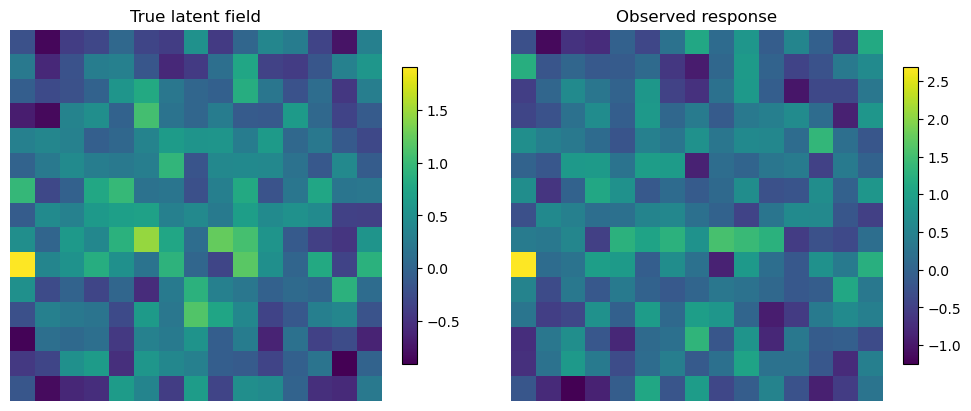

In [24]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

im0 = axes[0].imshow(
    phi_true.reshape(N_ROWS, N_COLS)
)

axes[0].set_title("True latent field")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(
    y.reshape(N_ROWS, N_COLS)
)

axes[1].set_title("Observed response")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.show()

In [25]:
def centered_block_mask(
    n_rows,
    n_cols,
    side,
):
    mask = np.zeros(
        (n_rows, n_cols),
        dtype=bool,
    )

    row_start = (n_rows - side) // 2
    col_start = (n_cols - side) // 2

    mask[
        row_start:row_start + side,
        col_start:col_start + side,
    ] = True

    return mask.ravel()


test_mask = centered_block_mask(
    N_ROWS,
    N_COLS,
    HOLDOUT_SIDE,
)

train_mask = ~test_mask

X_t = torch.ones(
    (N, 1),
    dtype=torch.double,
    device=device,
)

y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=device,
)

is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=device,
)

# Preserve held-out values for evaluation.
y_test_t = y_all_t[is_holdout_t].clone()

# Hide held-out values from the model.
y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan

prior_V0 = (
    10.0
    * torch.eye(
        1,
        dtype=torch.double,
        device=device,
    )
)


def graph_tensors(lam, U):
    return (
        torch.tensor(
            lam,
            dtype=torch.double,
            device=device,
        ),
        torch.tensor(
            U,
            dtype=torch.double,
            device=device,
        ),
    )


lam_true_t, U_true_t = graph_tensors(
    lam_true,
    U_true,
)

lam_fit_t, U_fit_t = graph_tensors(
    lam_fit,
    U_fit,
)

print("Training nodes:", train_mask.sum())
print("Held-out nodes:", test_mask.sum())

Training nodes: 200
Held-out nodes: 25


In [26]:
def make_leroux_filter():
    return LerouxCARFilterFullVI(
        mu_log_tau2=math.log(TAU2_TRUE),
        log_std_log_tau2=-2.3,
        mu_rho_raw=2.0,
        log_std_rho_raw=-2.3,
        fixed_rho=None,
        rho_eps=1e-4,
    ).to(device)


def make_sdm_filter(lam_t):
    lam_max = float(
        lam_t.max().item()
    )

    # Initialize the spline near the endpoint values
    # of the true Leroux spectrum.
    F_left = (
        TAU2_TRUE
        / (1.0 - RHO_TRUE)
    )

    F_right = (
        TAU2_TRUE
        / (
            (1.0 - RHO_TRUE)
            + RHO_TRUE * lam_max
        )
    )

    theta0_init = math.log(F_left)

    theta1_init = (
        math.log(F_right)
        - math.log(F_left)
    )

    return UnanchoredBSplineSpectrumFullVI(
        lam_max=lam_max,
        degree=SDM_DEGREE,
        n_internal_knots=SDM_INTERNAL_KNOTS,
        prior_std_theta=SDM_PRIOR_STD_THETA,
        prior_std_w=SDM_PRIOR_STD_W,
        log_std0=-2.3,
        init_theta=[
            theta0_init,
            theta1_init,
        ],
        init_w=0.0,
        logF_min=-30.0,
        logF_max=30.0,
    ).to(device)


def fit_model(
    *,
    label,
    lam_t,
    U_t,
    filter_module,
    iterations,
    learning_rate,
):
    torch.manual_seed(SEED)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_t,
        U=U_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=SIGMA2_TRUE,
        jitter=1e-8,
    ).to(device)

    # These are unused because sigma2 is fixed.
    model.mu_log_sigma2.requires_grad_(False)
    model.log_std_log_sigma2.requires_grad_(False)

    parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.Adam(
        parameters,
        lr=learning_rate,
    )

    history = []

    for iteration in range(iterations):
        optimizer.zero_grad(
            set_to_none=True
        )

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"{label}: non-finite loss "
                f"at iteration {iteration + 1}."
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            parameters,
            max_norm=GRAD_CLIP,
        )

        optimizer.step()

        history.append(
            float(elbo.detach().cpu())
        )

        if (iteration + 1) % 250 == 0:
            print(
                f"{label}: "
                f"iteration {iteration + 1}, "
                f"ELBO={history[-1]:.2f}"
            )

    prediction = model.predict_vi_mc(
        num_mc=PRED_MC,
    )

    return {
        "label": label,
        "model": model,
        "prediction": prediction,
        "history": history,
    }

In [27]:
oracle_leroux = fit_model(
    label="Oracle Leroux",
    lam_t=lam_true_t,
    U_t=U_true_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
)

wrong_leroux = fit_model(
    label="Wrong-W Leroux",
    lam_t=lam_fit_t,
    U_t=U_fit_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
)

wrong_sdm = fit_model(
    label="Wrong-W SDM-CAR",
    lam_t=lam_fit_t,
    U_t=U_fit_t,
    filter_module=make_sdm_filter(lam_fit_t),
    iterations=SDM_ITERS,
    learning_rate=SDM_LR,
)

Oracle Leroux: iteration 250, ELBO=6.62
Oracle Leroux: iteration 500, ELBO=5.72
Oracle Leroux: iteration 750, ELBO=7.34
Oracle Leroux: iteration 1000, ELBO=7.46
Wrong-W Leroux: iteration 250, ELBO=6.98
Wrong-W Leroux: iteration 500, ELBO=6.29
Wrong-W Leroux: iteration 750, ELBO=7.50
Wrong-W Leroux: iteration 1000, ELBO=7.71
Wrong-W SDM-CAR: iteration 250, ELBO=-39.18
Wrong-W SDM-CAR: iteration 500, ELBO=-19.48
Wrong-W SDM-CAR: iteration 750, ELBO=-9.47
Wrong-W SDM-CAR: iteration 1000, ELBO=-4.65
Wrong-W SDM-CAR: iteration 1250, ELBO=-3.52
Wrong-W SDM-CAR: iteration 1500, ELBO=-2.13


In [28]:
def prediction_mean(result):
    return (
        result["prediction"]["mean"]
        .detach()
        .cpu()
        .numpy()
    )


def rmse(actual, predicted):
    return float(
        np.sqrt(
            np.mean(
                (actual - predicted) ** 2
            )
        )
    )


y_test = y[test_mask]
eta_test = eta_true[test_mask]


def summarize_result(result):
    pred = prediction_mean(result)

    return {
        "model": result["label"],
        "test_y_rmse": rmse(
            y_test,
            pred,
        ),
        "test_eta_rmse": rmse(
            eta_test,
            pred,
        ),
    }


results = pd.DataFrame(
    [
        summarize_result(oracle_leroux),
        summarize_result(wrong_leroux),
        summarize_result(wrong_sdm),
    ]
)

results

,model,test_y_rmse,test_eta_rmse
0,Oracle Leroux,0.639298,0.511557
1,Wrong-W Leroux,0.642393,0.518596
2,Wrong-W SDM-CAR,0.626406,0.489265


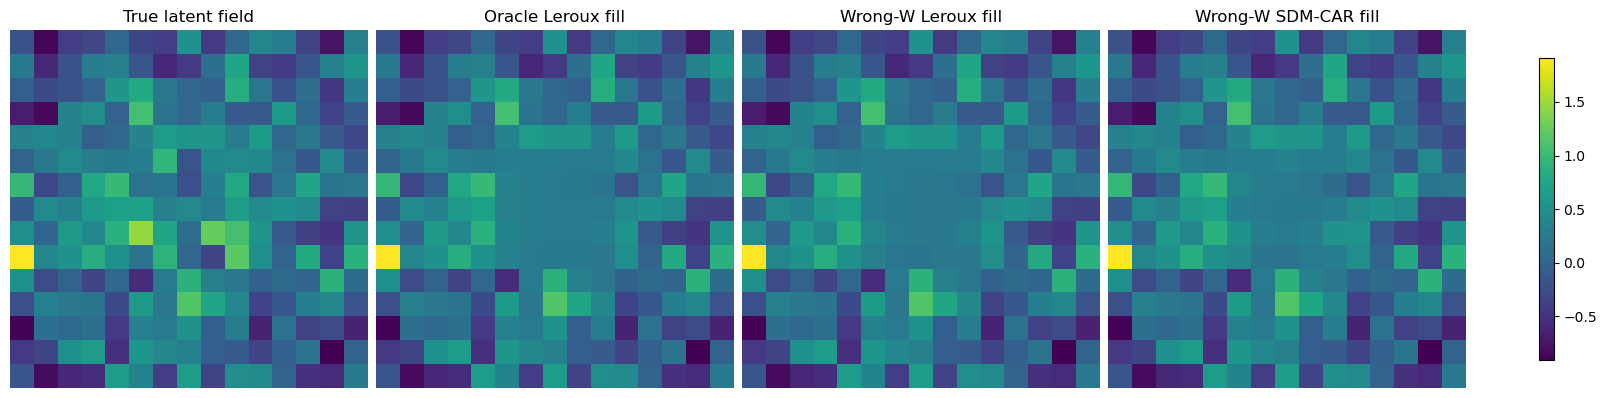

In [29]:
def make_fill_map(result):
    filled = eta_true.copy()

    filled[test_mask] = prediction_mean(
        result
    )

    return filled.reshape(
        N_ROWS,
        N_COLS,
    )


true_map = eta_true.reshape(
    N_ROWS,
    N_COLS,
)

oracle_map = make_fill_map(
    oracle_leroux
)

wrong_leroux_map = make_fill_map(
    wrong_leroux
)

wrong_sdm_map = make_fill_map(
    wrong_sdm
)

maps = [
    true_map,
    oracle_map,
    wrong_leroux_map,
    wrong_sdm_map,
]

titles = [
    "True latent field",
    "Oracle Leroux fill",
    "Wrong-W Leroux fill",
    "Wrong-W SDM-CAR fill",
]

vmin = min(
    field.min()
    for field in maps
)

vmax = max(
    field.max()
    for field in maps
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    constrained_layout=True,
)

for ax, field, title in zip(
    axes,
    maps,
    titles,
):
    image = ax.imshow(
        field,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title)
    ax.axis("off")

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
)

plt.show()